
# Phishing Website Detection — Training & Evaluation Notebook

Pipeline ini sepenuhnya mengacu pada `app.py` dan `train_model.py`:
- Feature extraction sesuai `extract_url_features()` di `app.py`
- Rule-based prefilter sesuai `rule_based_eval()` di `app.py`
- GA tuning, training, dan stacking sesuai `train_model.py`
- Decision logic: threshold `0.6`, mode `hybrid_prefilter` sesuai `FINAL_THRESHOLD` dan `DEFAULT_DECISION_MODE` di `app.py`
- Semua metrik dievaluasi: Accuracy, Precision, Recall, F1, AUC, TP/TN/FP/FN, Batch Throughput, Latency

**Dataset:** `DataFiles/data_cleaning.csv`  
**Random State:** 12 | **Test Size:** 20% | **Threshold:** 0.6  
**Model:** Random Forest + XGBoost + Stacking (GA-Tuned) | **Feature Mode:** URL-37 & Hybrid-81  
**Pipeline:** Load PKL → Evaluasi → Rule-Based Hybrid → Latency → SHAP (Global + Lokal) → Perbandingan

## 1. Import Library & Konfigurasi

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Import Library
# ═══════════════════════════════════════════════════════════════
import os
import json
import pathlib
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, confusion_matrix, average_precision_score
)

print('✅ Library berhasil di-import')

✅ Library berhasil di-import


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Konfigurasi Global
# ═══════════════════════════════════════════════════════════════
RANDOM_STATE = 12
TEST_SIZE    = 0.2
THRESHOLD    = 0.6
TARGET_COL   = 'label'

BASE_DIR  = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, 'DataFiles', 'data_cleaning.csv')
os.makedirs('results', exist_ok=True)

URL_FEATURES_37 = [
    'length_url','length_hostname','ip','nb_dots','nb_hyphens',
    'nb_at','nb_qm','nb_and','nb_eq','nb_underscore','nb_tilde',
    'nb_percent','nb_slash','nb_star','nb_colon','nb_comma',
    'nb_semicolumn','nb_dollar','nb_space','nb_www','nb_com',
    'nb_dslash','http_in_path','https_token','ratio_digits_url',
    'ratio_digits_host','punycode','port','tld_in_path',
    'tld_in_subdomain','abnormal_subdomain','nb_subdomains',
    'prefix_suffix','random_domain','shortening_service',
    'path_extension','nb_redirection'
]

COLORS_MAP = {
    'RF-37':'#90CAF9', 'XGB-37':'#42A5F5',
    'Stack-37':'#1565C0', 'Hybrid-37':'#0D47A1',
    'RF-81':'#80CBC4', 'XGB-81':'#26A69A',
    'Stack-81':'#00796B', 'Hybrid-81':'#004D40',
}

print(f'Base dir    : {BASE_DIR}')
print(f'Data path   : {DATA_PATH}')
print(f'Threshold   : {THRESHOLD}  |  Random state: {RANDOM_STATE}  |  Test size: {TEST_SIZE}')
print(f'URL features: {len(URL_FEATURES_37)} fitur')

Base dir    : c:\laragon\www\Phishing-Website-Detection-using-XGBoost-and-RFM
Data path   : c:\laragon\www\Phishing-Website-Detection-using-XGBoost-and-RFM\DataFiles\data_cleaning.csv
Threshold   : 0.6  |  Random state: 12  |  Test size: 0.2
URL features: 37 fitur


## 2. Data & Fitur

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Load Dataset & Eksplorasi
# ═══════════════════════════════════════════════════════════════
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print('=== Info Dataset ===')
print(f'Shape       : {df.shape[0]} baris × {df.shape[1]} kolom')
print(f'Duplikat    : {df.duplicated().sum()}')
print(f'Missing vals: {df.isnull().sum().sum()}')
print()

label_counts = df[TARGET_COL].value_counts()
print('=== Distribusi Label ===')
print(f'Benign   (0): {label_counts.get(0,0):,} ({label_counts.get(0,0)/len(df)*100:.1f}%)')
print(f'Phishing (1): {label_counts.get(1,0):,} ({label_counts.get(1,0)/len(df)*100:.1f}%)')
print()
display(df.head(3))

=== Info Dataset ===
Shape       : 11429 baris × 83 kolom
Duplikat    : 0
Missing vals: 0

=== Distribusi Label ===
Benign   (0): 5,715 (50.0%)
Phishing (1): 5,714 (50.0%)



,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,label
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,0
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,1
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,3,...,1,0,0,14,4004,5828815,0,1,0,1


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — Definisi Fitur & Pembagian Data (Train/Test)
# ═══════════════════════════════════════════════════════════════
id_cols      = [c for c in ['url'] if c in df.columns]
all_feats    = [c for c in df.columns if c not in [TARGET_COL] + id_cols]
web_feats_44 = [c for c in all_feats if c not in URL_FEATURES_37]
hybrid_81    = URL_FEATURES_37 + web_feats_44

print(f'Fitur URL-based (37)  : {len(URL_FEATURES_37)}')
print(f'Fitur Web-content (44): {len(web_feats_44)}')
print(f'Fitur Hybrid (81)     : {len(hybrid_81)}')

y_all = pd.to_numeric(df[TARGET_COL], errors='coerce')
df    = df.loc[y_all.notna()].copy()
y_all = y_all.loc[y_all.notna()].astype('int64')

train_idx, test_idx = train_test_split(
    df.index, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)

def make_xy(feats):
    avail = [c for c in feats if c in df.columns]
    X_tr  = df.loc[train_idx, avail].apply(pd.to_numeric, errors='coerce').dropna()
    X_te  = df.loc[test_idx,  avail].apply(pd.to_numeric, errors='coerce').dropna()
    y_tr  = y_all.loc[X_tr.index]
    y_te  = y_all.loc[X_te.index]
    return X_tr, X_te, y_tr, y_te

X_train_37, X_test_37, y_train_37, y_test_37 = make_xy(URL_FEATURES_37)
X_train_81, X_test_81, y_train_81, y_test_81 = make_xy(hybrid_81)

print(f'\nMode 37 → Train: {X_train_37.shape}, Test: {X_test_37.shape}')
print(f'Mode 81 → Train: {X_train_81.shape}, Test: {X_test_81.shape}')

Fitur URL-based (37)  : 37
Fitur Web-content (44): 44
Fitur Hybrid (81)     : 81

Mode 37 → Train: (9143, 37), Test: (2286, 37)
Mode 81 → Train: (9143, 81), Test: (2286, 81)


## 3. Load Model dari PKL

Model telah dilatih menggunakan **Genetic Algorithm (GA) Tuning** (populasi=16, generasi=8, 5-Fold CV)  
dan disimpan sebagai `.pkl`. Dimuat dari disk — **tanpa training ulang** — agar hasil konsisten dengan production.

In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Load Model dari PKL
# ═══════════════════════════════════════════════════════════════
def load_pkl(filename):
    path = os.path.join(BASE_DIR, filename)
    with open(path, 'rb') as f:
        return pickle.load(f)

def load_cols(filename):
    path = os.path.join(BASE_DIR, filename)
    with open(path, encoding='utf-8') as f:
        return [l.strip() for l in f if l.strip()]

def patch_lr(model):
    """Kompatibilitas sklearn ≥ 1.6: tambahkan multi_class jika tidak ada."""
    if not hasattr(model, 'multi_class'):
        model.multi_class = 'auto'
    return model

# Mode 37
rf37   = load_pkl('random_forest_model_37.pkl')
xgb37  = load_pkl('xgboost_model_37.pkl')
lr37   = patch_lr(load_pkl('rule_lr_37.pkl'))
cols37 = [c for c in load_cols('feature_columns_37.txt') if c in X_test_37.columns]
X_te37 = X_test_37[cols37]

# Mode 81
rf81   = load_pkl('random_forest_model_81.pkl')
xgb81  = load_pkl('xgboost_model_81.pkl')
lr81   = patch_lr(load_pkl('rule_lr_81.pkl'))
cols81 = [c for c in load_cols('feature_columns_81.txt') if c in X_test_81.columns]
X_te81 = X_test_81[cols81]

# Tampilkan hyperparameter GA dari JSON report
with open('ga_tuning_report_37.json') as f: rep37 = json.load(f)
with open('ga_tuning_report_81.json') as f: rep81 = json.load(f)

print('=== GA Best CV F1 ===')
print(f"Mode 37 → RF: {rep37['ga']['rf_best_cv_f1']:.4f}  |  XGB: {rep37['ga']['xgb_best_cv_f1']:.4f}")
print(f"Mode 81 → RF: {rep81['ga']['rf_best_cv_f1']:.4f}  |  XGB: {rep81['ga']['xgb_best_cv_f1']:.4f}")

print('\n--- Hyperparameter RF terbaik (Mode 81) ---')
rf_p = {k:v for k,v in rep81['ga']['rf_best_params'].items() if k not in ['random_state','n_jobs']}
display(pd.DataFrame(rf_p.items(), columns=['Hyperparameter','Nilai Optimal']))

print('--- Hyperparameter XGBoost terbaik (Mode 81) ---')
xgb_p = {k:v for k,v in rep81['ga']['xgb_best_params'].items()
          if k not in ['random_state','n_jobs','eval_metric']}
display(pd.DataFrame(xgb_p.items(), columns=['Hyperparameter','Nilai Optimal']))

print('\n✅ Semua model berhasil di-load')

=== GA Best CV F1 ===
Mode 37 → RF: 0.8736  |  XGB: 0.8800
Mode 81 → RF: 0.9638  |  XGB: 0.9666

--- Hyperparameter RF terbaik (Mode 81) ---


,Hyperparameter,Nilai Optimal
0,n_estimators,464
1,max_depth,14
2,min_samples_split,4
3,min_samples_leaf,1
4,max_features,log2


--- Hyperparameter XGBoost terbaik (Mode 81) ---


,Hyperparameter,Nilai Optimal
0,n_estimators,372.000000
1,learning_rate,0.126585
2,max_depth,5.000000
3,subsample,0.761040
4,colsample_bytree,0.711330
5,min_child_weight,3.867081
6,gamma,0.451126
7,reg_alpha,0.664309
8,reg_lambda,2.270156



✅ Semua model berhasil di-load


## 4. Evaluasi Model

Evaluasi pada **data test (20%)** yang tidak digunakan saat training.  
**Threshold: 0.6** — jika P(phishing) ≥ 0.6 → diklasifikasikan phishing.  
Metrik: Accuracy, Precision, Recall, F1-Score, AUC-ROC, TP, TN, FP, FN.

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Fungsi Evaluasi
# ═══════════════════════════════════════════════════════════════
def evaluate_model(name, y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall'   : recall_score(y_true, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_true, y_pred, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_true, y_prob),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        '_prob': y_prob, '_pred': y_pred,
        '_cm'  : confusion_matrix(y_true, y_pred, labels=[0,1])
    }

def predict_thr(model, X, thr=THRESHOLD):
    p = model.predict_proba(X)[:, 1]
    return (p >= thr).astype(int), p

def stacking_predict(lr, rf, xgb, X, thr=THRESHOLD):
    """Rekonstruksi prediksi stacking: [rf_prob, xgb_prob] → LR meta-learner."""
    rf_p  = rf.predict_proba(X)[:, 1]
    xgb_p = xgb.predict_proba(X)[:, 1]
    n_in  = int(getattr(lr, 'n_features_in_', 2))
    meta  = np.column_stack([rf_p, xgb_p])[:, :n_in]
    p     = lr.predict_proba(meta)[:, 1]
    return (p >= thr).astype(int), p

def display_cm(cm, title):
    df_cm = pd.DataFrame(cm,
        index=['Aktual Benign (0)','Aktual Phishing (1)'],
        columns=['Prediksi Benign (0)','Prediksi Phishing (1)'])
    print(f'\n🧩 Confusion Matrix — {title}')
    display(df_cm)

cols_show = ['Model','Accuracy','Precision','Recall','F1-Score','AUC-ROC','TP','TN','FP','FN']
print('✅ Fungsi evaluasi siap')

✅ Fungsi evaluasi siap


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Evaluasi Mode 37 Fitur (URL-based)
# ═══════════════════════════════════════════════════════════════
print('='*60)
print('  MODE 37 FITUR (URL-based)')
print('='*60)

y37 = y_test_37.loc[X_te37.index]

rf_pred37,  rf_prob37  = predict_thr(rf37,  X_te37)
xgb_pred37, xgb_prob37 = predict_thr(xgb37, X_te37)
stk_pred37, stk_prob37 = stacking_predict(lr37, rf37, xgb37, X_te37)

results_37 = [
    evaluate_model('RF-37',    y37, rf_pred37,  rf_prob37),
    evaluate_model('XGB-37',   y37, xgb_pred37, xgb_prob37),
    evaluate_model('Stack-37', y37, stk_pred37, stk_prob37),
]

df_res37 = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results_37])
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_res37[c] = df_res37[c].map('{:.4f}'.format)
print('\n📊 Hasil Evaluasi Mode 37 Fitur:')
display(df_res37[cols_show])
for r in results_37:
    display_cm(r['_cm'], r['Model'])

  MODE 37 FITUR (URL-based)

📊 Hasil Evaluasi Mode 37 Fitur:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,RF-37,0.8920,0.9125,0.8670,0.8892,0.9579,991,1048,95,152
1,XGB-37,0.8963,0.9187,0.8696,0.8935,0.9647,994,1055,88,149
2,Stack-37,0.9007,0.9111,0.8880,0.8994,0.9646,1015,1044,99,128



🧩 Confusion Matrix — RF-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1048,95
Aktual Phishing (1),152,991



🧩 Confusion Matrix — XGB-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1055,88
Aktual Phishing (1),149,994



🧩 Confusion Matrix — Stack-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1044,99
Aktual Phishing (1),128,1015


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Evaluasi Mode 81 Fitur (Hybrid)
# ═══════════════════════════════════════════════════════════════
print('='*60)
print('  MODE 81 FITUR (Hybrid)')
print('='*60)

y81 = y_test_81.loc[X_te81.index]

rf_pred81,  rf_prob81  = predict_thr(rf81,  X_te81)
xgb_pred81, xgb_prob81 = predict_thr(xgb81, X_te81)
stk_pred81, stk_prob81 = stacking_predict(lr81, rf81, xgb81, X_te81)

results_81 = [
    evaluate_model('RF-81',    y81, rf_pred81,  rf_prob81),
    evaluate_model('XGB-81',   y81, xgb_pred81, xgb_prob81),
    evaluate_model('Stack-81', y81, stk_pred81, stk_prob81),
]

df_res81 = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results_81])
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_res81[c] = df_res81[c].map('{:.4f}'.format)
print('\n📊 Hasil Evaluasi Mode 81 Fitur:')
display(df_res81[cols_show])
for r in results_81:
    display_cm(r['_cm'], r['Model'])

  MODE 81 FITUR (Hybrid)

📊 Hasil Evaluasi Mode 81 Fitur:


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,RF-81,0.9654,0.9828,0.9475,0.9648,0.9954,1083,1124,19,60
1,XGB-81,0.9764,0.9781,0.9746,0.9763,0.9969,1114,1118,25,29
2,Stack-81,0.9751,0.9772,0.9729,0.9750,0.9963,1112,1117,26,31



🧩 Confusion Matrix — RF-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1124,19
Aktual Phishing (1),60,1083



🧩 Confusion Matrix — XGB-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1118,25
Aktual Phishing (1),29,1114



🧩 Confusion Matrix — Stack-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),1117,26
Aktual Phishing (1),31,1112


## 5. Rule-Based Filtering & Hybrid

Prefilter rule-based dijalankan **sebelum** model ML.  
Aturan terbagi 3 tingkat: *very important* (langsung phishing), *important* (skor ×2), *less important* (skor ×1).  
Jika rule menangkap → probabiiltas dinaikkan ke ≥ 0.95, lalu threshold 0.6 diterapkan.

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Fungsi Rule-Based Vectorized (identik app.py)
# 24 rule rule-based prefilter, sesuai rule_based_eval() di app.py
# ═══════════════════════════════════════════════════════════════
def rule_flag(X_df):
    def col(name, default=0):
        return X_df[name].fillna(default).values if name in X_df.columns else np.full(len(X_df), default)

    # Sangat Penting: satu fitur saja → langsung Phishing (4 rule, kategori "Sangat Penting")
    vi = (
        (col('suspicious_tld')     == 1) |
        (col('random_domain')      == 1) |
        (col('ip')                 == 1) |
        (col('http_in_path')       == 1)
    )
    # Penting: bobot ×2 (17 rule, kategori "Penting")
    imp = (
        (col('nb_at')           >= 1  ).astype(int) +
        (col('nb_subdomains')   >  3  ).astype(int) +
        (col('nb_dots')         >  4  ).astype(int) +
        (col('nb_slash')        >  7  ).astype(int) +
        (col('length_hostname') >  30 ).astype(int) +
        (col('nb_percent')      >  5  ).astype(int) +
        (col('nb_tilde')        >= 1  ).astype(int) +
        (col('nb_semicolumn')   >= 1  ).astype(int) +
        (col('nb_star')         >= 1  ).astype(int) +
        (col('nb_comma')        >= 1  ).astype(int) +
        (col('nb_dollar')       >= 1  ).astype(int) +
        (col('nb_qm')           >  2  ).astype(int) +
        (col('nb_colon')        >  1  ).astype(int) +
        (col('nb_eq')           >  8  ).astype(int) +
        (col('nb_and')          >  3  ).astype(int) +
        (col('nb_hyphens')      >  3  ).astype(int) +
        (col('nb_underscore')   >  3  ).astype(int)
    )
    # Cukup Penting: bobot ×1 (3 rule, kategori "Cukup Penting")
    less = (
        (col('ratio_digits_url')   > 0.3).astype(int) +
        (col('port')               == 1 ).astype(int) +
        (col('shortening_service') == 1 ).astype(int)
    )
    return (vi | (2 * imp + less >= 5)).astype(int)

print('✅ Fungsi rule-based siap (24 rule)')

✅ Fungsi rule-based siap (24 rule)


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Evaluasi Hybrid (Rule-Based + Stacking)
# ═══════════════════════════════════════════════════════════════
def hybrid_predict(X_df, stack_prob, thr=THRESHOLD):
    rule  = rule_flag(X_df)
    hyb_p = np.where(rule == 1, np.maximum(stack_prob, 0.95), stack_prob)
    return (hyb_p >= thr).astype(int), hyb_p, int(rule.sum())

# Mode 37
hyb_pred37, hyb_prob37, n_rule37 = hybrid_predict(X_te37, stk_prob37)
res_hyb37 = evaluate_model('Hybrid-37', y37, hyb_pred37, hyb_prob37)

# Mode 81
hyb_pred81, hyb_prob81, n_rule81 = hybrid_predict(X_te81, stk_prob81)
res_hyb81 = evaluate_model('Hybrid-81', y81, hyb_pred81, hyb_prob81)

results_37.append(res_hyb37)
results_81.append(res_hyb81)

df_hyb = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                        for r in [res_hyb37, res_hyb81]])
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_hyb[c] = df_hyb[c].map('{:.4f}'.format)

print('=== Hasil Evaluasi Hybrid ===')
display(df_hyb[cols_show])
print(f'\nURL ditangkap rule (Mode 37): {n_rule37}/{len(X_te37)} ({n_rule37/len(X_te37)*100:.1f}%)')
print(f'URL ditangkap rule (Mode 81): {n_rule81}/{len(X_te81)} ({n_rule81/len(X_te81)*100:.1f}%)')
display_cm(res_hyb37['_cm'], 'Hybrid-37')
display_cm(res_hyb81['_cm'], 'Hybrid-81')

=== Hasil Evaluasi Hybrid ===


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,Hybrid-37,0.8635,0.8397,0.8985,0.8681,0.9208,1027,947,196,116
1,Hybrid-81,0.9256,0.8852,0.9781,0.9293,0.9878,1118,998,145,25



URL ditangkap rule (Mode 37): 536/2286 (23.4%)
URL ditangkap rule (Mode 81): 560/2286 (24.5%)

🧩 Confusion Matrix — Hybrid-37


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),947,196
Aktual Phishing (1),116,1027



🧩 Confusion Matrix — Hybrid-81


,Prediksi Benign (0),Prediksi Phishing (1)
Aktual Benign (0),998,145
Aktual Phishing (1),25,1118


## 6. Analisis Latency

Mengukur kecepatan inference:
- **Batch throughput**: prediksi seluruh data test (5 run, diambil rata-rata)
- **Latency per-URL**: prediksi 1 URL (20 run, diambil rata-rata, min, max, std)

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Benchmark Latency (4 Eksperimen, Mode 81)
# ═══════════════════════════════════════════════════════════════
N_BATCH   = 5
N_LATENCY = 20
X_single  = X_te81.iloc[[0]]

def fn_rf(X):
    p = rf81.predict_proba(X)[:, 1]
    return (p >= THRESHOLD).astype(int), p

def fn_xgb(X):
    p = xgb81.predict_proba(X)[:, 1]
    return (p >= THRESHOLD).astype(int), p

def fn_stack(X):
    rf_p  = rf81.predict_proba(X)[:, 1]
    xgb_p = xgb81.predict_proba(X)[:, 1]
    p     = lr81.predict_proba(np.column_stack([rf_p, xgb_p])[:, :2])[:, 1]
    return (p >= THRESHOLD).astype(int), p

def fn_hybrid(X):
    _, stk_p = fn_stack(X)
    d, p, _  = hybrid_predict(X, stk_p)
    return d, p

experiments = [
    ('Random Forest (81)',      fn_rf),
    ('XGBoost (81)',            fn_xgb),
    ('Stacking RF+XGB (81)',    fn_stack),
    ('Hybrid Rule+Stack (81)',  fn_hybrid),
]

batch_rows, latency_rows = [], []

for name, fn in experiments:
    # Batch throughput
    times = [time.perf_counter() or fn(X_te81) or time.perf_counter()
             for _ in range(N_BATCH)]
    bt = []
    for _ in range(N_BATCH):
        t0 = time.perf_counter(); fn(X_te81); bt.append(time.perf_counter()-t0)
    avg_b = np.mean(bt)
    batch_rows.append({'Model':name, 'Batch Time (s)':round(avg_b,4),
                       'Throughput (URL/s)':round(len(X_te81)/avg_b,1)})
    # Latency per-URL
    lt = []
    for _ in range(N_LATENCY):
        t0 = time.perf_counter(); fn(X_single); lt.append(time.perf_counter()-t0)
    latency_rows.append({'Model':name, 'Avg (ms)':round(np.mean(lt)*1000,3),
                         'Min (ms)':round(np.min(lt)*1000,3),
                         'Max (ms)':round(np.max(lt)*1000,3),
                         'Std (ms)':round(np.std(lt)*1000,3)})

print('📊 Batch Throughput (seluruh data test)')
display(pd.DataFrame(batch_rows))
print('\n⚡ Latency Per-URL (1 URL)')
display(pd.DataFrame(latency_rows))

📊 Batch Throughput (seluruh data test)


,Model,Batch Time (s),Throughput (URL/s)
0,Random Forest (81),0.1813,12607.0
1,XGBoost (81),0.0222,102832.3
2,Stacking RF+XGB (81),0.1972,11593.1
3,Hybrid Rule+Stack (81),0.1736,13164.7



⚡ Latency Per-URL (1 URL)


,Model,Avg (ms),Min (ms),Max (ms),Std (ms)
0,Random Forest (81),117.247,72.672,159.430,23.000
1,XGBoost (81),12.426,9.623,22.808,3.166
2,Stacking RF+XGB (81),134.313,113.274,241.678,31.367
3,Hybrid Rule+Stack (81),119.318,102.043,137.765,10.880


## 7. SHAP Analysis

**SHAP (SHapley Additive exPlanations)** mengukur kontribusi tiap fitur terhadap prediksi model.

### Yang akan dianalisis:
| Sub-bagian | Isi |
|---|---|
| **A. Global SHAP** | Rata-rata `mean(|SHAP|)` untuk **3 model** (RF, XGB, Stacking) — bar chart + beeswarm |
| **B. Perbandingan Global** | Satu grafik gabungan: top-10 fitur ketiga model berdampingan |
| **C. Local SHAP** | Waterfall plot per URL × per model dari `log_feature_extraction.csv` |
| **D. Export CSV** | Seluruh kontribusi SHAP lokal diekspor ke `shap_local_export.csv` |

### Cara membaca plot:
- **Bar chart (global)**: panjang bar = seberapa besar rata-rata pengaruh fitur → **fitur paling penting di atas**
- **Beeswarm (global)**: setiap titik = satu sampel; warna merah = nilai fitur tinggi, biru = rendah; posisi kanan = mendorong ke phishing, kiri = ke benign
- **Waterfall (lokal)**: mulai dari `E[f(x)]` (baseline), tiap fitur menambah atau mengurangi probabilitas phishing; bar merah = menaikkan risiko, biru = menurunkan

### Catatan teknis:
- `shap.TreeExplainer` digunakan untuk RF dan XGB (cepat, exact)
- Stacking menggunakan `shap.Explainer` auto-detect (fallback ke `KernelExplainer` jika perlu)
- Background sample: 200 data training; sample global: 500 data test

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — SHAP Setup & Helper Functions
# ═══════════════════════════════════════════════════════════════
# Gunakan X_train_81 dan X_te81 (mode 81 fitur = informasi paling lengkap)
X_train_shap = X_train_81[[c for c in cols81 if c in X_train_81.columns]]

TOP_N        = 10
SHAP_BG_SIZE   = min(200, len(X_train_shap))
SHAP_GLOBAL_SZ = min(500, len(X_te81))

X_background  = shap.utils.sample(X_train_shap, SHAP_BG_SIZE, random_state=RANDOM_STATE)
X_global_shap = shap.utils.sample(X_te81, SHAP_GLOBAL_SZ, random_state=RANDOM_STATE)

print(f'Background  : {X_background.shape}')
print(f'Global SHAP : {X_global_shap.shape}')
print(f'Top N       : {TOP_N}')


# ── Helper: ambil SHAP values untuk kelas phishing (class=1) ─────────────────
def _select_class1(explanation):
    values = np.asarray(explanation.values)
    base   = np.asarray(explanation.base_values)
    if values.ndim == 3:
        values = values[:, :, 1]
        if base.ndim == 2: base = base[:, 1]
    if base.ndim == 0:
        base = np.repeat(float(base), values.shape[0])
    return values, base


# ── Helper: normalisasi output SHAP ke 2D (n_samples, n_features) ────────────
def _normalize_shap_vals(raw, n_features):
    """
    Tangani berbagai format output SHAP:
      - list of arrays per kelas  → ambil index 1 (phishing)
      - ndarray 3D (n,f,2)        → ambil [:,:,1]
      - ndarray 2D (n,f)          → langsung pakai
    Output selalu float64 dengan shape (n_samples, n_features).
    """
    if isinstance(raw, list):
        arr = np.asarray(raw[1] if len(raw) > 1 else raw[0])
    else:
        arr = np.asarray(raw)
    if arr.ndim == 3:
        arr = arr[:, :, 1]
    elif arr.ndim == 1:
        arr = arr.reshape(1, -1)
    return arr[:, :n_features].astype(float)


# ── Helper: compute SHAP dengan auto-fallback ke KernelExplainer ─────────────
def compute_shap(model, X_explain, background):
    """
    Coba shap.Explainer (TreeExplainer untuk tree-based, paling cepat dan exact).
    Jika gagal (misal model Stacking/LR), fallback ke KernelExplainer dengan
    background kecil (50 sampel) agar tidak terlalu lambat.
    """
    n_feat = X_explain.shape[1]
    try:
        exp  = shap.Explainer(model, background)
        expl = exp(X_explain)
        vals, base = _select_class1(expl)
        vals = _normalize_shap_vals(vals, n_feat)
        return vals, base
    except Exception as e:
        print(f'  Auto explainer gagal: {e}')
        print('  → Fallback ke KernelExplainer (lebih lambat)...')
        bg_small = shap.sample(background, min(50, len(background)))
        exp  = shap.KernelExplainer(model.predict_proba, bg_small)
        raw  = exp.shap_values(X_explain, nsamples=100)
        vals = _normalize_shap_vals(raw, n_feat)
        bv   = np.asarray(exp.expected_value).flatten()
        bv   = float(bv[1] if len(bv) > 1 else bv[0])
        return vals, np.repeat(bv, vals.shape[0])


print('✅ SHAP helper functions siap')

Background  : (200, 81)
Global SHAP : (500, 81)
Top N       : 10
✅ SHAP helper functions siap



  Global SHAP — Random Forest (GA)


 99%|===================| 994/1000 [02:49<00:01]        

Top 10 fitur paling berpengaruh:


,feature,mean_abs_shap
0,google_index,0.0888
1,page_rank,0.0749
2,nb_hyperlinks,0.0418
3,web_traffic,0.0391
4,nb_www,0.0358
5,domain_age,0.0220
6,phish_hints,0.0195
7,safe_anchor,0.0157
8,longest_word_path,0.0130
9,ratio_digits_url,0.0130


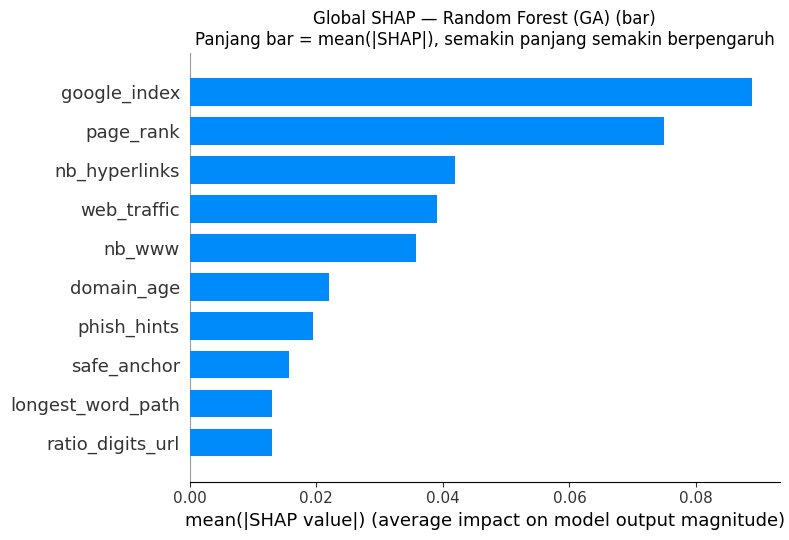

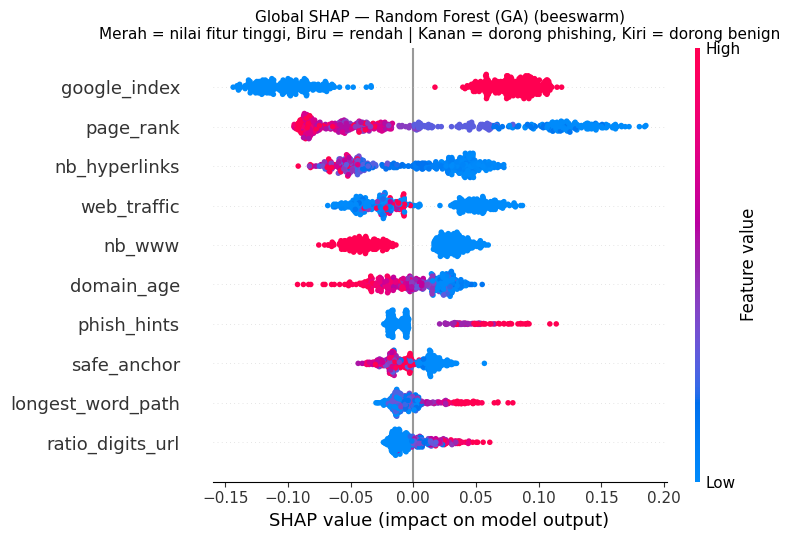


  Global SHAP — XGBoost (GA)
Top 10 fitur paling berpengaruh:


,feature,mean_abs_shap
0,page_rank,1.5294
1,google_index,1.1084
2,nb_www,0.9198
3,nb_hyperlinks,0.7248
4,phish_hints,0.5188
5,domain_age,0.4267
6,nb_hyphens,0.3780
7,web_traffic,0.3631
8,nb_slash,0.3504
9,length_hostname,0.3152


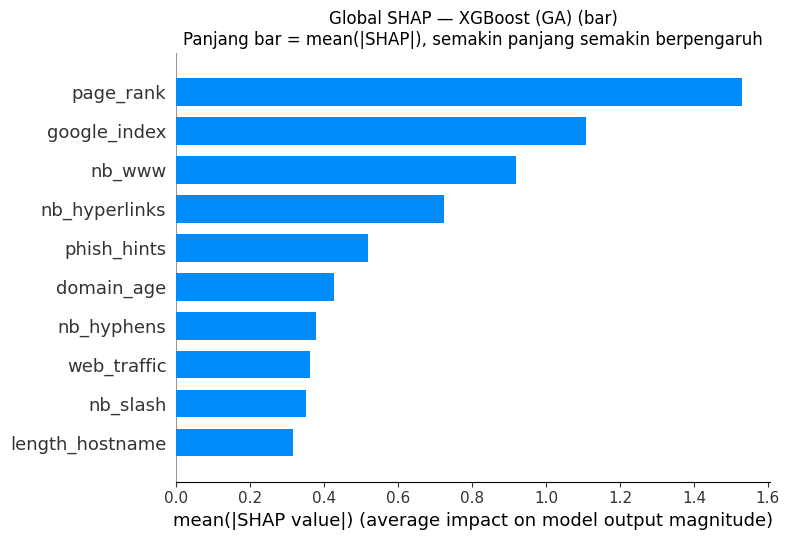

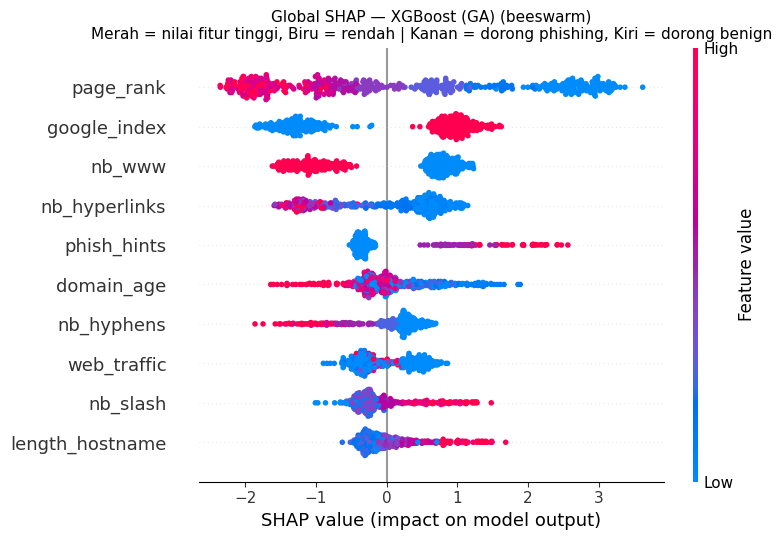


  Global SHAP — Stacking (RF+XGB+LR, GA)


PermutationExplainer explainer: 501it [05:12,  1.59it/s]                         

Top 10 fitur paling berpengaruh:


,feature,mean_abs_shap
0,page_rank,0.1084
1,google_index,0.0938
2,nb_www,0.0472
3,nb_hyperlinks,0.0463
4,web_traffic,0.0282
5,phish_hints,0.0245
6,domain_age,0.0212
7,safe_anchor,0.0143
8,longest_word_path,0.0130
9,nb_hyphens,0.0126


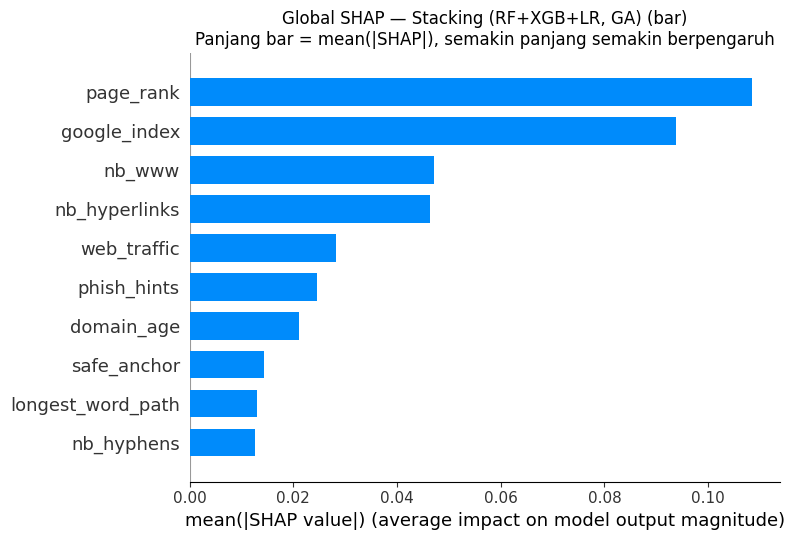

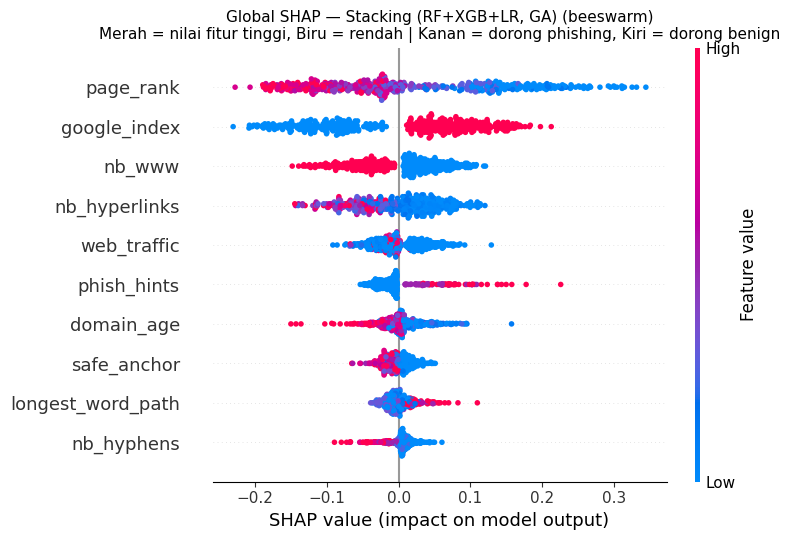


✅ Global SHAP selesai untuk semua model


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — SHAP Global: 3 Model (RF, XGB, Stacking)
# Bar chart + Beeswarm per model
# ═══════════════════════════════════════════════════════════════
#
# ⚠️  Stacking tidak bisa di-SHAP secara langsung via lr81
#     karena lr81 adalah meta-learner yang hanya menerima 2 input
#     (rf_prob, xgb_prob), bukan 81 fitur asli.
#
#     Solusi: bungkus pipeline stacking dalam wrapper function
#     agar SHAP menerima 81 fitur → hasilkan [rf_prob, xgb_prob]
#     → teruskan ke lr81. Wrapper ini persis logika stacking_predict().

import pandas as pd
import numpy as np

class StackingWrapper:
    """
    Wrapper agar shap.Explainer bisa menghitung SHAP untuk
    pipeline Stacking secara end-to-end (81 fitur → probabilitas).

    Alur:
      X (81 fitur) → rf81.predict_proba → rf_p
                   → xgb81.predict_proba → xgb_p
      [rf_p, xgb_p] → lr81.predict_proba → output [p_benign, p_phishing]
    """
    def __init__(self, rf, xgb, lr):
        self.rf  = rf
        self.xgb = xgb
        self.lr  = lr

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X_arr = X.values
        else:
            X_arr = np.asarray(X)
        rf_p  = self.rf.predict_proba(X_arr)[:, 1]
        xgb_p = self.xgb.predict_proba(X_arr)[:, 1]
        n_in  = int(getattr(self.lr, 'n_features_in_', 2))
        meta  = np.column_stack([rf_p, xgb_p])[:, :n_in]
        return self.lr.predict_proba(meta)  # shape (n, 2)

    def __call__(self, X):
        return self.predict_proba(X)


# Inisialisasi wrapper stacking
stacking_wrapper = StackingWrapper(rf81, xgb81, lr81)

# Definisi model yang akan di-SHAP:
# RF dan XGB langsung menggunakan model asli (TreeExplainer — cepat & exact)
# Stacking menggunakan wrapper (KernelExplainer via fallback — lebih lambat)
SHAP_MODELS = {
    'Random Forest (GA)':        rf81,
    'XGBoost (GA)':              xgb81,
    'Stacking (RF+XGB+LR, GA)': stacking_wrapper,
}

global_shap_results = {}   # {model_name: (shap_vals, global_df)}

for model_name, model in SHAP_MODELS.items():
    print(f"\n{'='*60}")
    print(f'  Global SHAP — {model_name}')
    print(f"{'='*60}")

    shap_vals, base_vals = compute_shap(model, X_global_shap, X_background)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    mean_abs = np.asarray(mean_abs).flatten()[:len(X_global_shap.columns)]

    global_df = (
        pd.DataFrame({'feature': list(X_global_shap.columns), 'mean_abs_shap': mean_abs})
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )
    global_shap_results[model_name] = (shap_vals, global_df)

    print(f'Top {TOP_N} fitur paling berpengaruh:')
    display(global_df.head(TOP_N).style.format({'mean_abs_shap': '{:.4f}'}))

    safe = model_name.lower().replace(' ','_').replace('(','').replace(')','').replace('+','')

    # Bar chart
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_global_shap, plot_type='bar', max_display=TOP_N, show=False)
    plt.title(f'Global SHAP — {model_name} (bar)\n'
              f'Panjang bar = mean(|SHAP|), semakin panjang semakin berpengaruh', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'results/shap_global_bar_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Beeswarm
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_vals, X_global_shap, max_display=TOP_N, show=False)
    plt.title(f'Global SHAP — {model_name} (beeswarm)\n'
              f'Merah = nilai fitur tinggi, Biru = rendah | Kanan = dorong phishing, Kiri = dorong benign',
              fontsize=11)
    plt.tight_layout()
    plt.savefig(f'results/shap_global_beeswarm_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n✅ Global SHAP selesai untuk semua model")

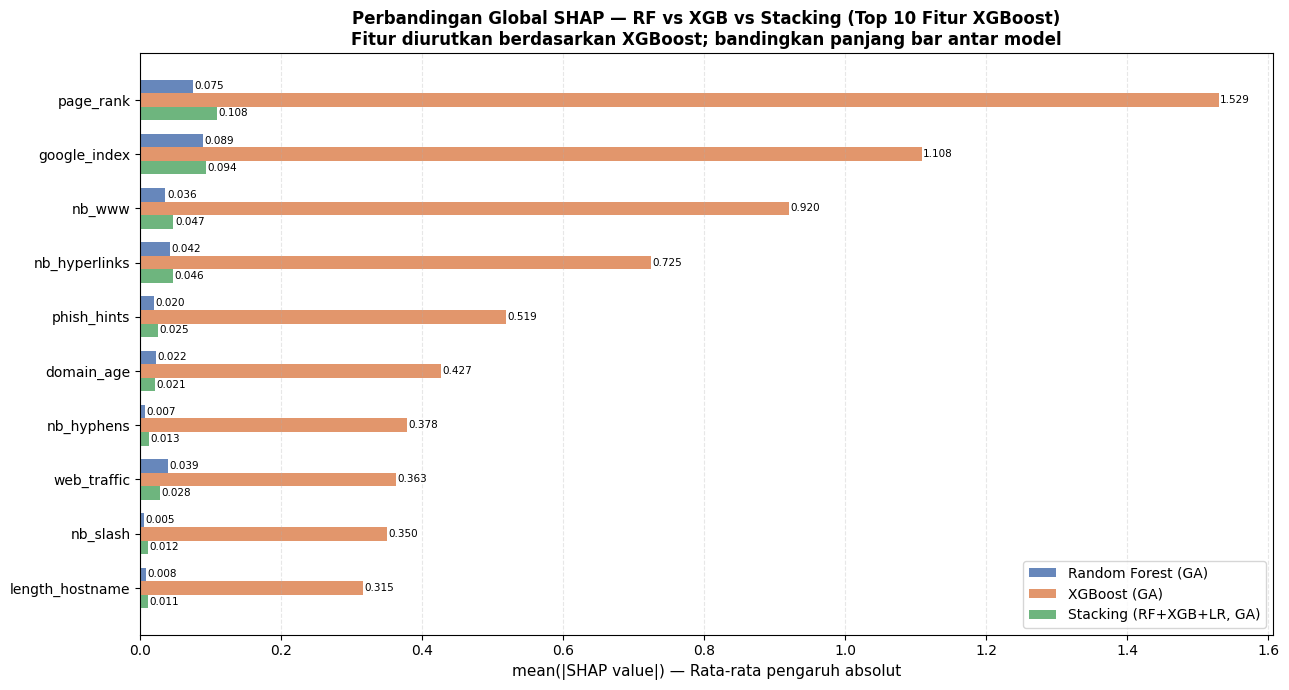

✅ Grafik perbandingan global SHAP disimpan


In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — Perbandingan Global SHAP: RF vs XGB vs Stacking
# (satu grafik gabungan, top-10 fitur berdampingan)
# ═══════════════════════════════════════════════════════════════
# Ambil top-10 fitur berdasarkan XGBoost sebagai referensi
ref_model  = 'XGBoost (GA)'
top_feats  = global_shap_results[ref_model][1]['feature'].head(TOP_N).tolist()

fig, ax = plt.subplots(figsize=(13, 7))
x     = np.arange(len(top_feats))
w     = 0.25
colors_m = {
    'Random Forest (GA)':       '#4C72B0',
    'XGBoost (GA)':             '#DD8452',
    'Stacking (RF+XGB+LR, GA)': '#55A868',
}
offsets = {'Random Forest (GA)': -w, 'XGBoost (GA)': 0, 'Stacking (RF+XGB+LR, GA)': w}

for model_name, (_, gdf) in global_shap_results.items():
    vals = [gdf.set_index('feature')['mean_abs_shap'].get(f, 0) for f in top_feats]
    bars = ax.barh(x + offsets[model_name], vals, w,
                   label=model_name, color=colors_m[model_name], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=7.5)

ax.set_yticks(x)
ax.set_yticklabels(top_feats, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('mean(|SHAP value|) — Rata-rata pengaruh absolut', fontsize=11)
ax.set_title(
    f'Perbandingan Global SHAP — RF vs XGB vs Stacking (Top {TOP_N} Fitur XGBoost)\n'
    'Fitur diurutkan berdasarkan XGBoost; bandingkan panjang bar antar model',
    fontsize=12, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('results/shap_global_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik perbandingan global SHAP disimpan')

Empat URL yang akan dijelaskan SHAP:


,URL,STATUS,PHISHING_PROB
0,https://numpy.org/doc/,phishing,0.6515
1,http://www.kueronekayacotn-co-jp.kueronekayaco...,phishing,0.9500
2,https://www.ietf.org/,benign,0.3597
3,https://drive-shared-docs.verify-user.co/open/...,benign,0.4298



[1/3] Menghitung SHAP lokal — Random Forest...
[2/3] Menghitung SHAP lokal — XGBoost...
[3/3] Menghitung SHAP lokal — Stacking (KernelExplainer, lebih lambat)...


100%|██████████| 4/4 [00:00<00:00,  4.19it/s]


✅ Semua SHAP lokal selesai

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 1: https://numpy.org/doc/
  Label  : PHISHING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cara baca waterfall: bar merah = fitur mendorong ke PHISHING,
  bar biru = mendorong ke BENIGN. Dimulai dari E[f(x)] (baseline).

  ▶ Random Forest (GA)
    p_phishing = 0.6377 → Prediksi: PHISHING (BENAR ✅)


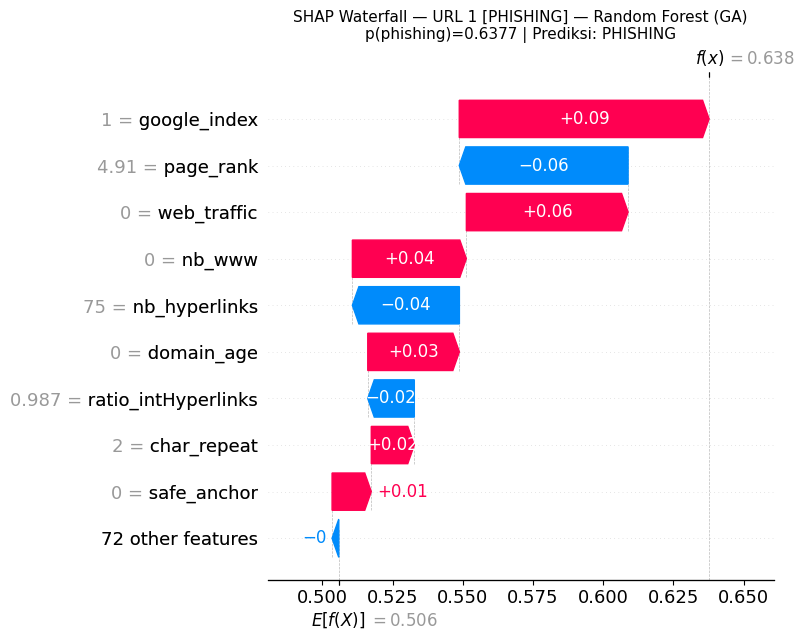


  ▶ XGBoost (GA)
    p_phishing = 0.4466 → Prediksi: BENIGN (SALAH ❌)


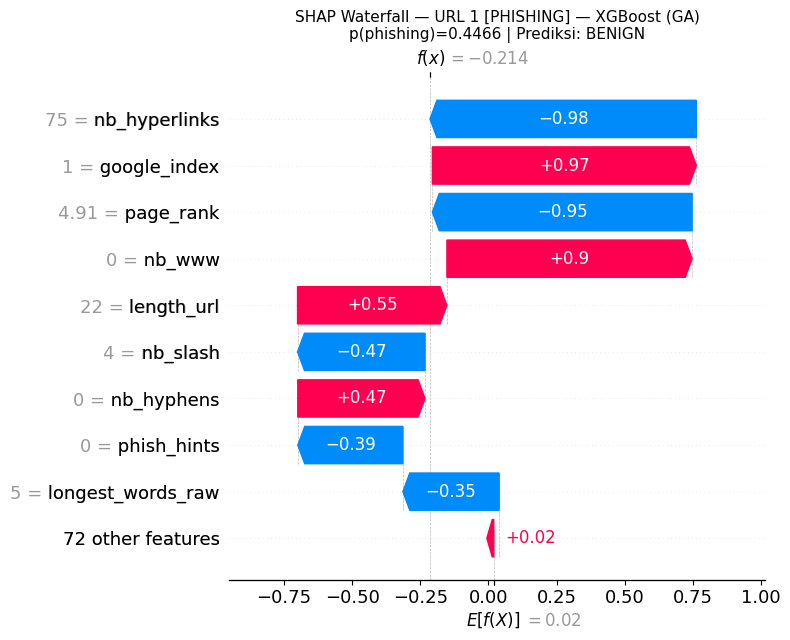


  ▶ Stacking (RF+XGB+LR, GA)
    p_phishing = 0.6515 → Prediksi: PHISHING (BENAR ✅)


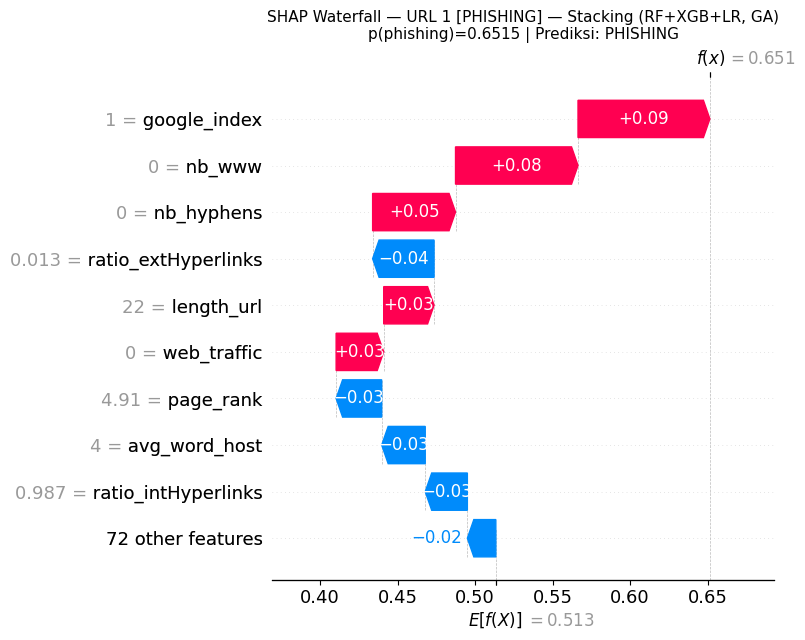


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 2: http://www.kueronekayacotn-co-jp.kueronekayacotn.rvxxkq.top/ai/?authenticated=true&amp;amp;openid/gp/signin/x&amp;amp;i=a&amp;amp;oauth=m&amp;amp;i?ie=utf8&amp;amp;ref_=rhf_custrec_signin6a906d6920fa43de76f847daeb0940fff77e45ae
  Label  : PHISHING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cara baca waterfall: bar merah = fitur mendorong ke PHISHING,
  bar biru = mendorong ke BENIGN. Dimulai dari E[f(x)] (baseline).

  ▶ Random Forest (GA)
    p_phishing = 0.8215 → Prediksi: PHISHING (BENAR ✅)


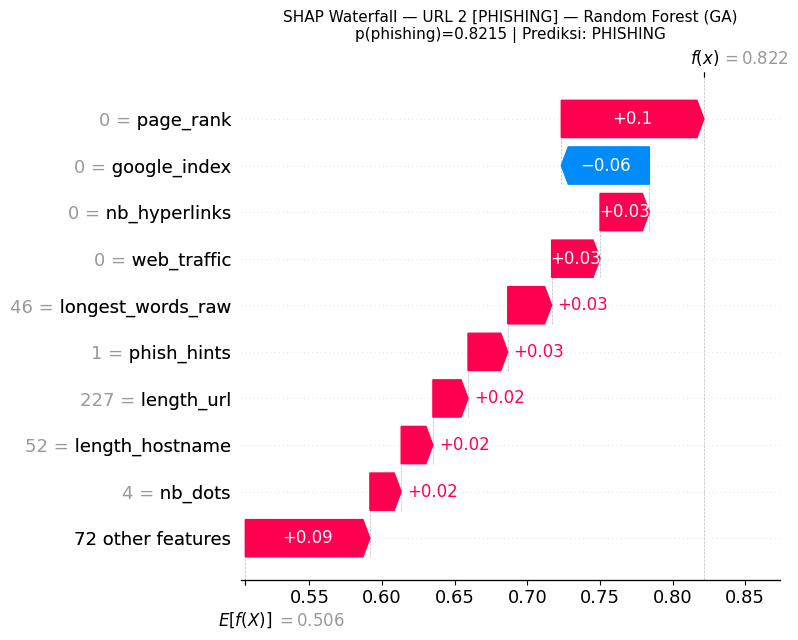


  ▶ XGBoost (GA)
    p_phishing = 0.9975 → Prediksi: PHISHING (BENAR ✅)


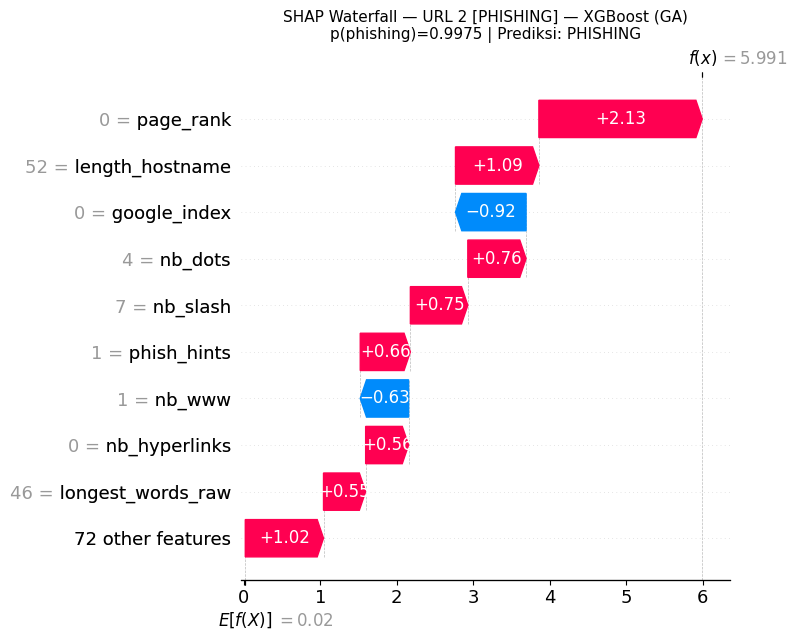


  ▶ Stacking (RF+XGB+LR, GA)
    p_phishing = 0.9759 → Prediksi: PHISHING (BENAR ✅)


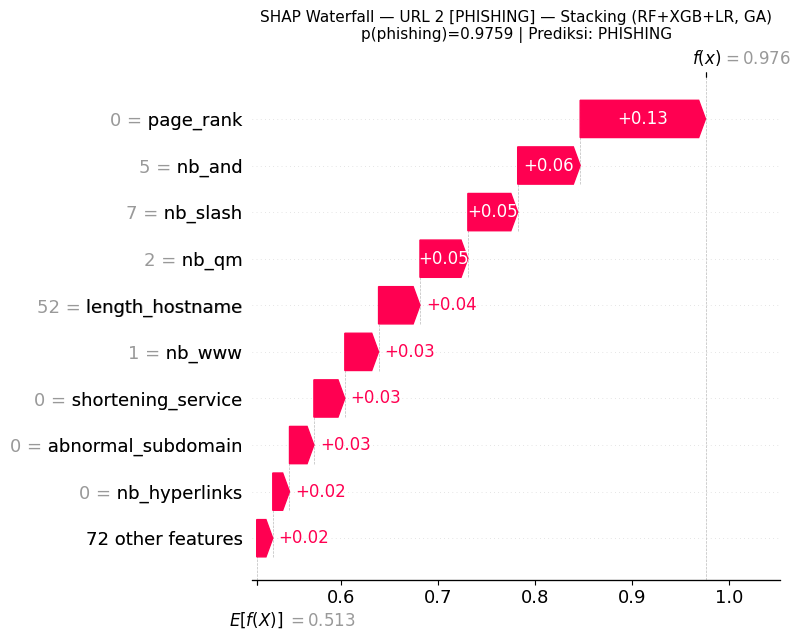


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 3: https://www.ietf.org/
  Label  : BENIGN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cara baca waterfall: bar merah = fitur mendorong ke PHISHING,
  bar biru = mendorong ke BENIGN. Dimulai dari E[f(x)] (baseline).

  ▶ Random Forest (GA)
    p_phishing = 0.3597 → Prediksi: BENIGN (BENAR ✅)


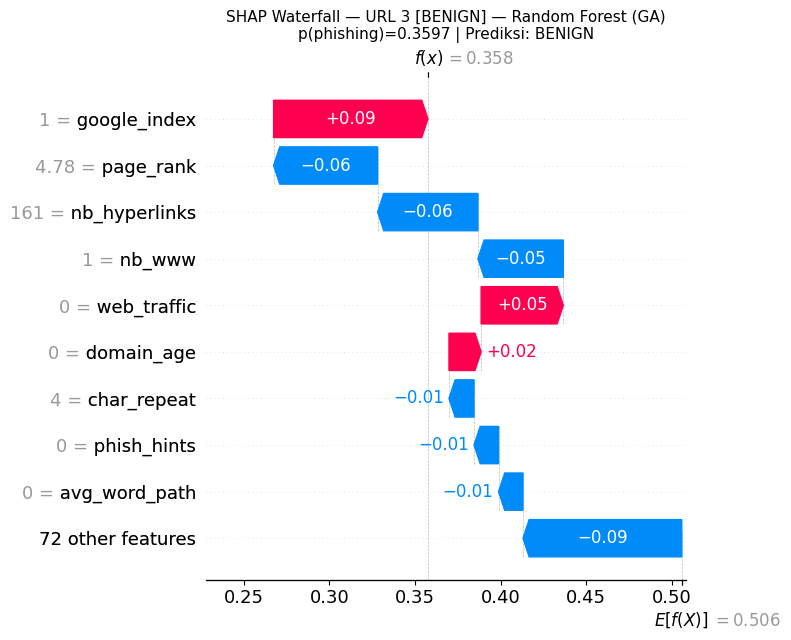


  ▶ XGBoost (GA)
    p_phishing = 0.0265 → Prediksi: BENIGN (BENAR ✅)


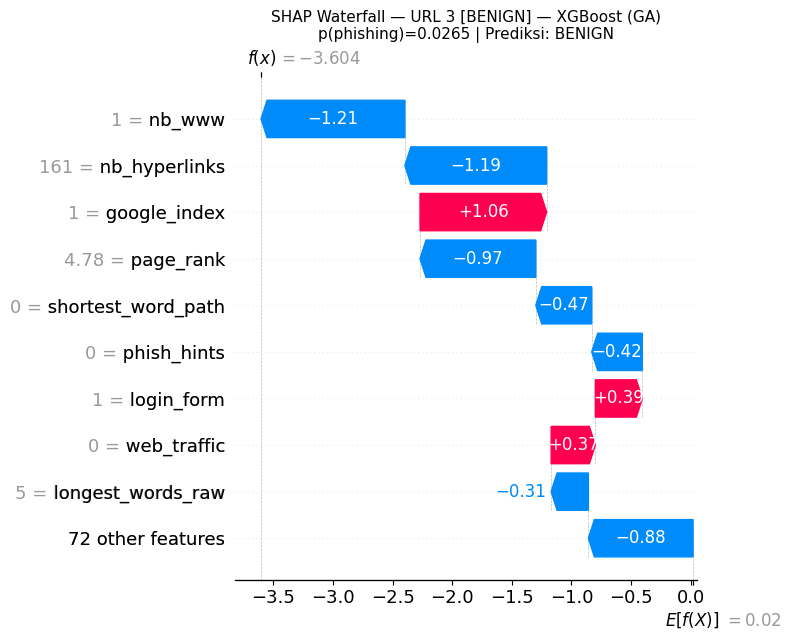


  ▶ Stacking (RF+XGB+LR, GA)
    p_phishing = 0.0721 → Prediksi: BENIGN (BENAR ✅)


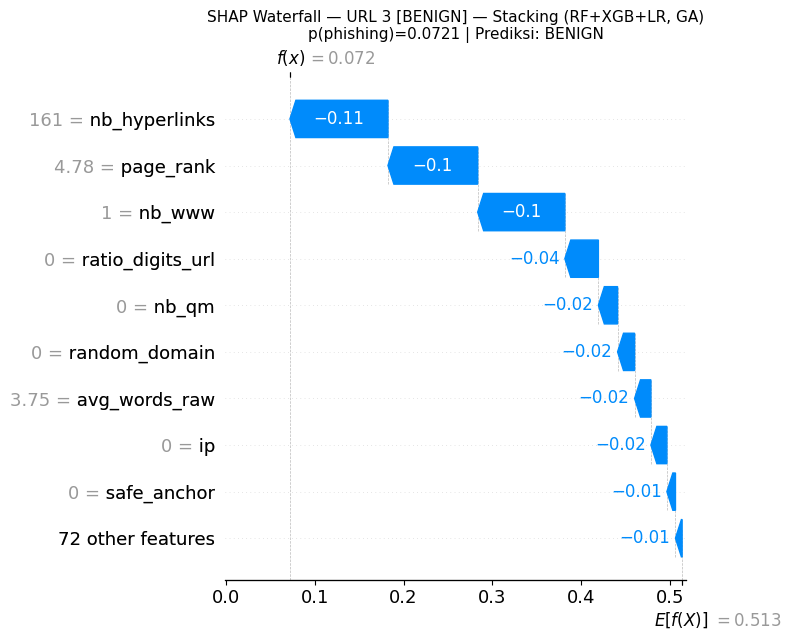


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  URL 4: https://drive-shared-docs.verify-user.co/open/view.php
  Label  : BENIGN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Cara baca waterfall: bar merah = fitur mendorong ke PHISHING,
  bar biru = mendorong ke BENIGN. Dimulai dari E[f(x)] (baseline).

  ▶ Random Forest (GA)
    p_phishing = 0.7955 → Prediksi: PHISHING (SALAH ❌)


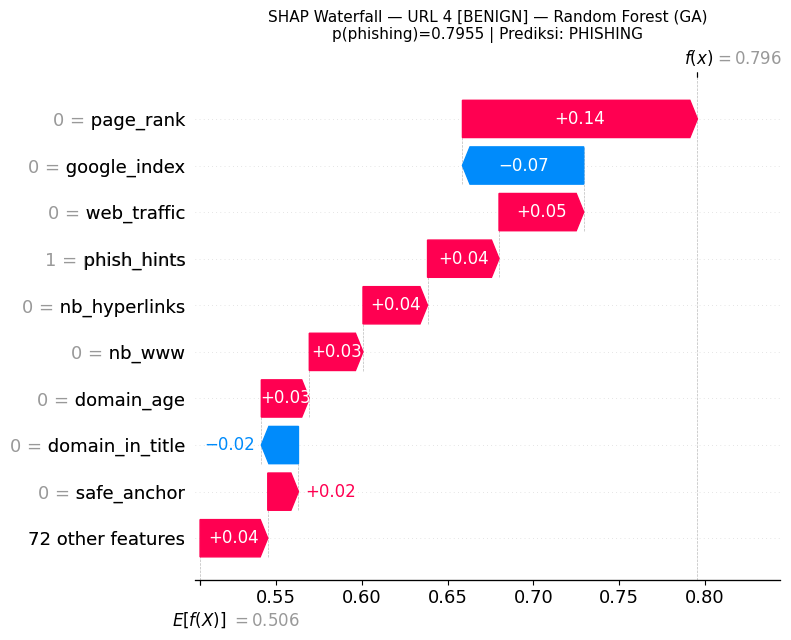


  ▶ XGBoost (GA)
    p_phishing = 0.9915 → Prediksi: PHISHING (SALAH ❌)


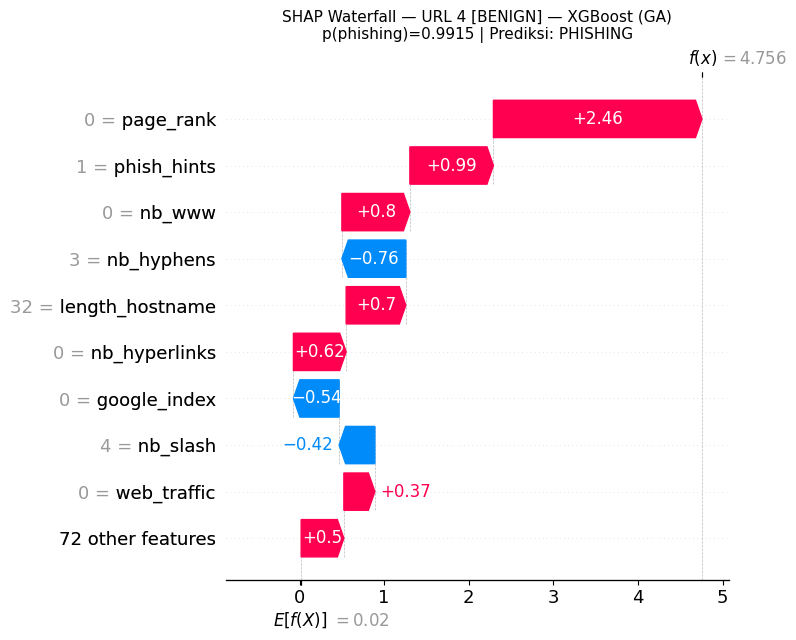


  ▶ Stacking (RF+XGB+LR, GA)
    p_phishing = 0.9713 → Prediksi: PHISHING (SALAH ❌)


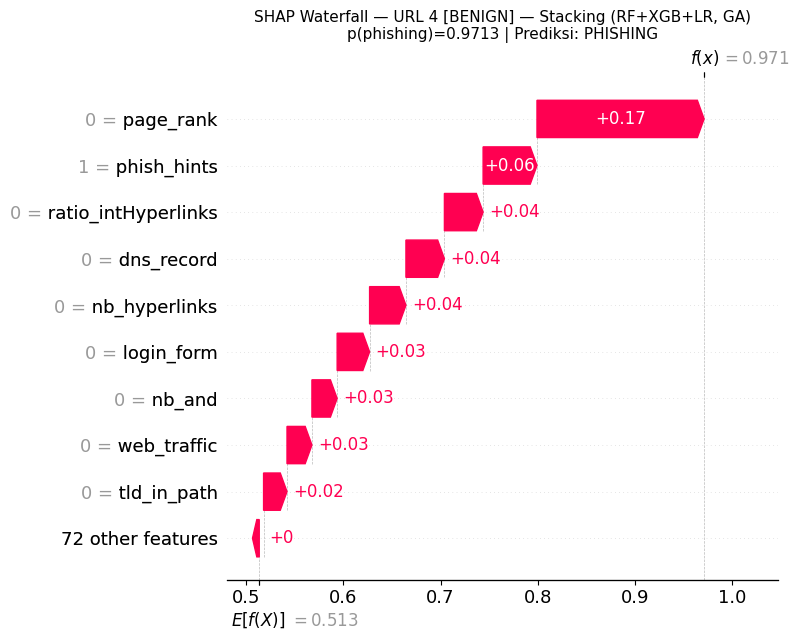


────────────────────────────────────────────────────────────
  Export SHAP lokal ke CSV...
✅ Diekspor ke results/shap_local_export.csv (120 baris)
   Kolom: url_no | url | status | model | p_phishing | prediction |
          rank | feature | feature_value | shap_signed | abs_shap | direction


,url_no,url,status,model,p_phishing,prediction,rank,feature,feature_value,shap_signed,abs_shap,direction
0,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,1,google_index,1.000000,0.088992,0.088992,PHISHING
1,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,2,page_rank,4.910000,-0.060136,0.060136,BENIGN
2,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,3,web_traffic,0.000000,0.057608,0.057608,PHISHING
3,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,4,nb_www,0.000000,0.040597,0.040597,PHISHING
4,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,5,nb_hyperlinks,75.000000,-0.038119,0.038119,BENIGN
5,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,6,domain_age,0.000000,0.032640,0.032640,PHISHING
6,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,7,ratio_intHyperlinks,0.986667,-0.016585,0.016585,BENIGN
7,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,8,char_repeat,2.000000,0.015327,0.015327,PHISHING
8,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,9,safe_anchor,0.000000,0.013967,0.013967,PHISHING
9,1,https://numpy.org/doc/,phishing,Random Forest (GA),0.6377,PHISHING,10,ratio_digits_url,0.000000,-0.012034,0.012034,BENIGN


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — SHAP Lokal: Waterfall dari log_feature_extraction.csv
# ═══════════════════════════════════════════════════════════════
# File log ditulis app.py dengan separator ";" dan encoding utf-8-sig.
# Kolom LLM_REASONING mengandung koma bebas → pd.read_csv() default
# akan error "Expected N fields, saw N+k" → harus pakai sep=";".
#
# ⚠️  Stacking: sama seperti CELL 13, gunakan stacking_wrapper
#     (bukan lr81 langsung) agar input 81 fitur diproses benar.
#
# ⚠️  compute_shap untuk Stacking: shap.Explainer auto-detect
#     model sebagai LinearModel → route ke LinearExplainer yang
#     salah. Solusi: paksa KernelExplainer via force_kernel=True.

def compute_shap_kernel(model, X_explain, background, nsamples=100):
    """
    Hitung SHAP menggunakan KernelExplainer secara eksplisit.
    Digunakan untuk model non-tree (Stacking/wrapper) agar tidak
    salah-route ke LinearExplainer.
    Background dikecilkan ke 50 sampel untuk efisiensi.
    """
    n_feat   = X_explain.shape[1]
    bg_small = shap.sample(background, min(50, len(background)))
    exp      = shap.KernelExplainer(model.predict_proba, bg_small)
    raw      = exp.shap_values(X_explain, nsamples=nsamples)
    vals     = _normalize_shap_vals(raw, n_feat)
    bv       = np.asarray(exp.expected_value).flatten()
    bv_scalar = float(bv[1] if len(bv) > 1 else bv[0])
    return vals, np.repeat(bv_scalar, vals.shape[0])


log_csv_path = pathlib.Path('log_feature_extraction.csv')

if log_csv_path.exists():
    log_df = pd.read_csv(
        log_csv_path,
        sep=';',
        on_bad_lines='warn',
        encoding='utf-8-sig',
        low_memory=False,
    )
    log_df.columns = log_df.columns.str.strip()

    missing_req = [c for c in ['URL', 'STATUS'] if c not in log_df.columns]
    if missing_req:
        raise ValueError(f'Kolom wajib tidak ditemukan: {missing_req}\n'
                         f'Kolom tersedia: {log_df.columns.tolist()}')

    # Ambil 4 baris terakhir yang unik (berbeda URL)
    local_log = (
        log_df
        .drop_duplicates(subset=['URL'], keep='last')
        .tail(4)
        .copy()
        .reset_index(drop=True)
    )
    print('Empat URL yang akan dijelaskan SHAP:')
    disp_cols = ['URL','STATUS'] + (['PHISHING_PROB'] if 'PHISHING_PROB' in local_log.columns else [])
    display(local_log[disp_cols])

    feature_cols = list(X_te81.columns)
    missing_feat = [c for c in feature_cols if c not in local_log.columns]
    if missing_feat:
        print(f'⚠️  {len(missing_feat)} fitur tidak ada di log, diisi 0: {missing_feat[:5]}...')

    X_local = (
        local_log
        .reindex(columns=feature_cols, fill_value=0)
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)
    )

    # ── Hitung SHAP lokal ─────────────────────────────────────────────────────
    # RF & XGB: gunakan compute_shap biasa (TreeExplainer — cepat)
    print('\n[1/3] Menghitung SHAP lokal — Random Forest...')
    shap_local_rf,  base_rf  = compute_shap(rf81,              X_local, X_background)
    print('[2/3] Menghitung SHAP lokal — XGBoost...')
    shap_local_xgb, base_xgb = compute_shap(xgb81,            X_local, X_background)
    # Stacking: WAJIB pakai compute_shap_kernel (KernelExplainer eksplisit)
    # karena shap.Explainer salah-route ke LinearExplainer untuk objek wrapper
    print('[3/3] Menghitung SHAP lokal — Stacking (KernelExplainer, lebih lambat)...')
    shap_local_stk, base_stk = compute_shap_kernel(stacking_wrapper, X_local, X_background)
    print('✅ Semua SHAP lokal selesai')

    # ── Probabilitas prediksi ─────────────────────────────────────────────────
    proba_rf  = rf81.predict_proba(X_local)[:, 1]
    proba_xgb = xgb81.predict_proba(X_local)[:, 1]
    proba_stk_m = stacking_wrapper.predict_proba(X_local)[:, 1]

    MODEL_LOCAL = [
        ('Random Forest (GA)',        shap_local_rf,  base_rf,  proba_rf,     'rf'),
        ('XGBoost (GA)',              shap_local_xgb, base_xgb, proba_xgb,    'xgb'),
        ('Stacking (RF+XGB+LR, GA)', shap_local_stk, base_stk, proba_stk_m,  'stk'),
    ]

    # ── Waterfall per URL × per model ─────────────────────────────────────────
    for i in range(len(X_local)):
        label_ = str(local_log.loc[i, 'STATUS']).upper()
        url_   = local_log.loc[i, 'URL']
        print(f"\n{'━'*70}")
        print(f'  URL {i+1}: {url_}')
        print(f'  Label  : {label_}')
        print(f"{'━'*70}")
        print('  Cara baca waterfall: bar merah = fitur mendorong ke PHISHING,')
        print('  bar biru = mendorong ke BENIGN. Dimulai dari E[f(x)] (baseline).')

        for model_name, shap_loc, base_loc, proba_arr, safe_key in MODEL_LOCAL:
            p_    = proba_arr[i]
            pred_ = 'PHISHING' if p_ >= THRESHOLD else 'BENIGN'
            conf_ = 'BENAR ✅' if pred_ == label_ else 'SALAH ❌'
            print(f'\n  ▶ {model_name}')
            print(f'    p_phishing = {p_:.4f} → Prediksi: {pred_} ({conf_})')

            exp_i = shap.Explanation(
                values=shap_loc[i],
                base_values=base_loc[i],
                data=X_local.iloc[i].values,
                feature_names=feature_cols,
            )
            shap.plots.waterfall(exp_i, max_display=TOP_N, show=False)
            plt.title(
                f'SHAP Waterfall — URL {i+1} [{label_}] — {model_name}\n'
                f'p(phishing)={p_:.4f} | Prediksi: {pred_}',
                fontsize=11
            )
            plt.tight_layout()
            plt.savefig(f'results/shap_waterfall_url{i+1}_{safe_key}.png',
                        dpi=150, bbox_inches='tight')
            plt.show()

    # ── Export ringkasan SHAP lokal ke CSV ────────────────────────────────────
    print(f"\n{'─'*60}")
    print('  Export SHAP lokal ke CSV...')
    local_rows = []
    for i in range(len(X_local)):
        for model_name, shap_loc, _, proba_arr, _ in MODEL_LOCAL:
            signed  = shap_loc[i]
            top_idx = np.argsort(np.abs(signed))[::-1][:TOP_N]
            for rank, j in enumerate(top_idx, 1):
                local_rows.append({
                    'url_no':        i + 1,
                    'url':           local_log.loc[i, 'URL'],
                    'status':        local_log.loc[i, 'STATUS'],
                    'model':         model_name,
                    'p_phishing':    round(float(proba_arr[i]), 4),
                    'prediction':    'PHISHING' if proba_arr[i] >= THRESHOLD else 'BENIGN',
                    'rank':          rank,
                    'feature':       feature_cols[j],
                    'feature_value': float(X_local.iloc[i, j]),
                    'shap_signed':   round(float(signed[j]), 6),
                    'abs_shap':      round(float(abs(signed[j])), 6),
                    'direction':     'PHISHING' if signed[j] > 0 else 'BENIGN',
                })

    local_shap_df = pd.DataFrame(local_rows)
    local_shap_df.to_csv('results/shap_local_export.csv', index=False)
    print(f'✅ Diekspor ke results/shap_local_export.csv ({len(local_shap_df)} baris)')
    print('   Kolom: url_no | url | status | model | p_phishing | prediction |')
    print('          rank | feature | feature_value | shap_signed | abs_shap | direction')
    display(local_shap_df.head(20))

else:
    print('⚠️  log_feature_extraction.csv tidak ditemukan — lewati local SHAP.')
    print('   Letakkan file log (separator=;) di folder yang sama dengan notebook.')
    print()
    print('   Fallback: tampilkan local SHAP dari data test (2 phishing + 2 benign).')

    y81_arr = y81.values
    xgb_p81 = xgb81.predict_proba(X_te81)[:, 1]
    xgb_d81 = (xgb_p81 >= THRESHOLD).astype(int)

    idx_ph = np.where((xgb_d81 == 1) & (y81_arr == 1))[0][:2]
    idx_bn = np.where((xgb_d81 == 0) & (y81_arr == 0))[0][:2]
    sample_idx = list(idx_ph) + list(idx_bn)
    labels_fb  = ['Phishing #1','Phishing #2','Benign #1','Benign #2']

    X_fb = X_te81.iloc[sample_idx]
    shap_fb, base_fb = compute_shap(xgb81, X_fb, X_background)
    proba_fb = xgb81.predict_proba(X_fb)[:, 1]

    for i, (pos, lab) in enumerate(zip(sample_idx, labels_fb)):
        p_ = proba_fb[i]
        print(f'\n  ▶ XGBoost — {lab} | p_phishing={p_:.4f}')
        exp_i = shap.Explanation(
            values=shap_fb[i], base_values=base_fb[i],
            data=X_fb.iloc[i].values, feature_names=list(X_te81.columns)
        )
        shap.plots.waterfall(exp_i, max_display=TOP_N, show=False)
        plt.title(f'SHAP Waterfall — {lab} (dari data test)\np(phishing)={p_:.4f}', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'results/shap_waterfall_fallback_{i+1}.png', dpi=150, bbox_inches='tight')
        plt.show()

## 8. Perbandingan Model

In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — Tabel Perbandingan Lengkap (8 Model)
# ═══════════════════════════════════════════════════════════════
all_results = results_37 + results_81

df_all = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                        for r in all_results])
df_all_pct = df_all.copy()
for c in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    df_all_pct[c] = (df_all_pct[c] * 100).round(2).astype(str) + '%'

print('📊 Perbandingan Semua Model (Threshold = 0.6):')
display(df_all_pct[cols_show])

📊 Perbandingan Semua Model (Threshold = 0.6):


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,TP,TN,FP,FN
0,RF-37,89.2%,91.25%,86.7%,88.92%,95.79%,991,1048,95,152
1,XGB-37,89.63%,91.87%,86.96%,89.35%,96.47%,994,1055,88,149
2,Stack-37,90.07%,91.11%,88.8%,89.94%,96.46%,1015,1044,99,128
3,Hybrid-37,86.35%,83.97%,89.85%,86.81%,92.08%,1027,947,196,116
4,RF-81,96.54%,98.28%,94.75%,96.48%,99.54%,1083,1124,19,60
5,XGB-81,97.64%,97.81%,97.46%,97.63%,99.69%,1114,1118,25,29
6,Stack-81,97.51%,97.72%,97.29%,97.5%,99.63%,1112,1117,26,31
7,Hybrid-81,92.56%,88.52%,97.81%,92.93%,98.78%,1118,998,145,25


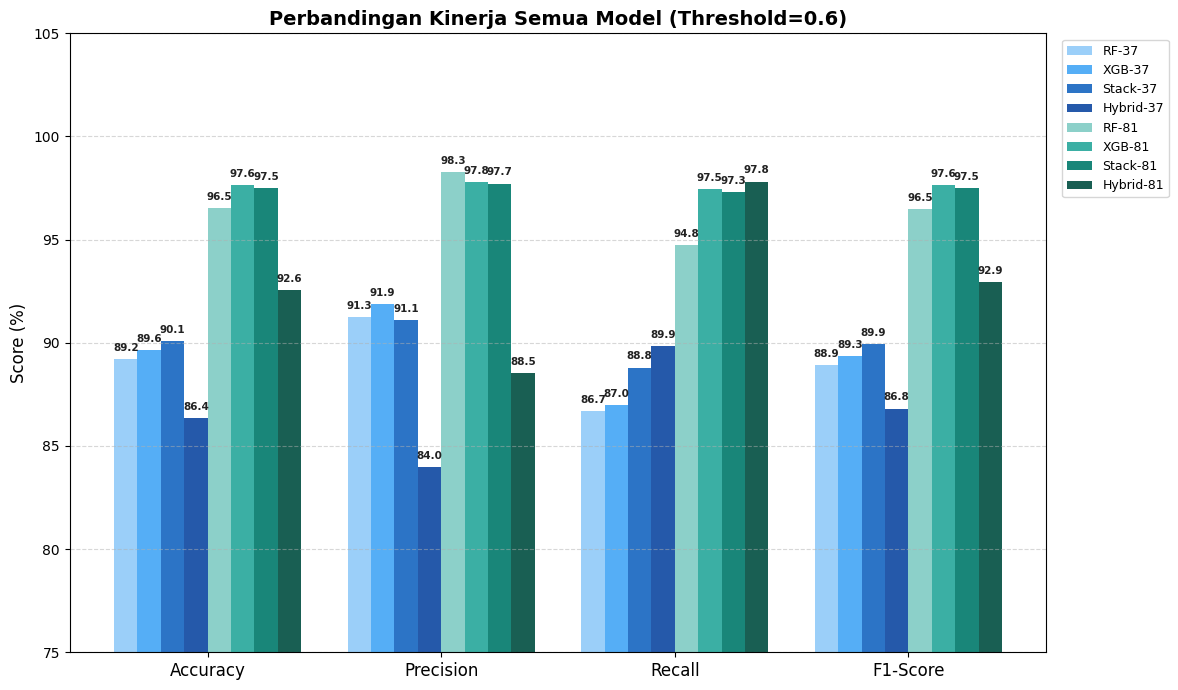

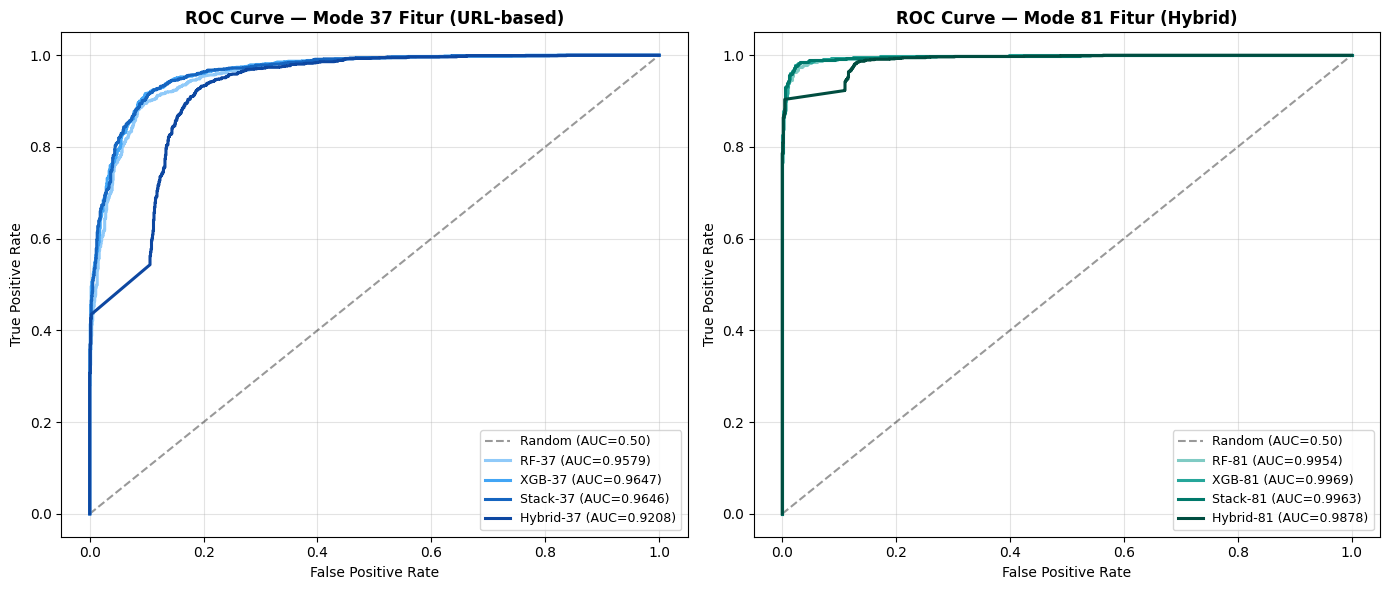

✅ Visualisasi tersimpan di folder results/


In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — Visualisasi Perbandingan (Bar + ROC)
# ═══════════════════════════════════════════════════════════════
metrics_plot = ['Accuracy','Precision','Recall','F1-Score']
n     = len(all_results)
x     = np.arange(len(metrics_plot))
width = 0.10

# ── Bar chart Acc/Prec/Rec/F1 ──
fig, ax = plt.subplots(figsize=(14, 7))
for i, r in enumerate(all_results):
    offset = (i - n/2 + 0.5) * width
    vals   = [r[m] * 100 for m in metrics_plot]
    
    bars = ax.bar(x + offset, vals, width, label=r['Model'],
                  color=COLORS_MAP[r['Model']], alpha=0.9)
    
    # Tambahkan angka secara horizontal di atas setiap bar
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,          # Pas di tengah lebar bar
            height + 0.3,                               # Sedikit di atas ujung bar
            f'{height:.1f}',                            # Format angka (contoh: 89.2), tanpa "%" biar ga kepanjangan
            ha='center',                                # Center alignment horizontal
            va='bottom',                                # Botton alignment vertikal
            fontsize=7.5,                               # Ukuran font kecil supaya muat horizontal
            fontweight='bold',                          # Ditebalkan seperti contoh gambar kamu
            color='#222222'                             # Warna teks abu-abu gelap/hitam
        )

ax.set_xticks(x)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1-Score'], fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Perbandingan Kinerja Semua Model (Threshold=0.6)', fontsize=14, fontweight='bold')
ax.set_ylim(75, 105) # Dikembalikan ke 105 atau sesuaikan jika teks paling atas mentok
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left', bbox_to_anchor=(1.01,1), fontsize=9)
plt.tight_layout(rect=[0,0,0.85,1])
plt.savefig('results/01_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ROC Curve ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
groups = [
    ('Mode 37 Fitur (URL-based)', results_37, y37),
    ('Mode 81 Fitur (Hybrid)',    results_81, y81),
]
for ax, (title, rlist, y_true) in zip(axes, groups):
    ax.plot([0,1],[0,1],'k--',alpha=0.4, label='Random (AUC=0.50)')
    for r in rlist:
        fpr, tpr, _ = roc_curve(y_true, r['_prob'])
        ax.plot(fpr, tpr, color=COLORS_MAP[r['Model']], lw=2.2,
                label=f"{r['Model']} (AUC={r['AUC-ROC']:.4f})")
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {title}', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('results/02_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Visualisasi tersimpan di folder results/')